In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

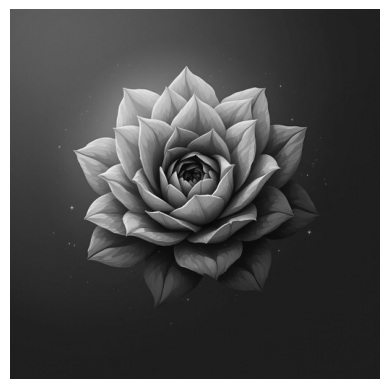

In [3]:
img = cv2.imread('rose.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap='gray')
plt.axis('off')

(a) Decrease its spatial resolution by half ev ery time and observe its change when displaying in the same window size

In [15]:
def resize(img, size):
    nw,nh = size
    ow,oh = img.shape
    resize_img = np.zeros((nh,nw), dtype=img.dtype)

    sx = ow/nw
    sy = oh/nh

    for y in range(nh):
        for x in range(nw):
            src_x = int(sx*x)
            src_y = int(sy*y)
            resize_img[y,x] = img[src_y, src_x]
    return resize_img

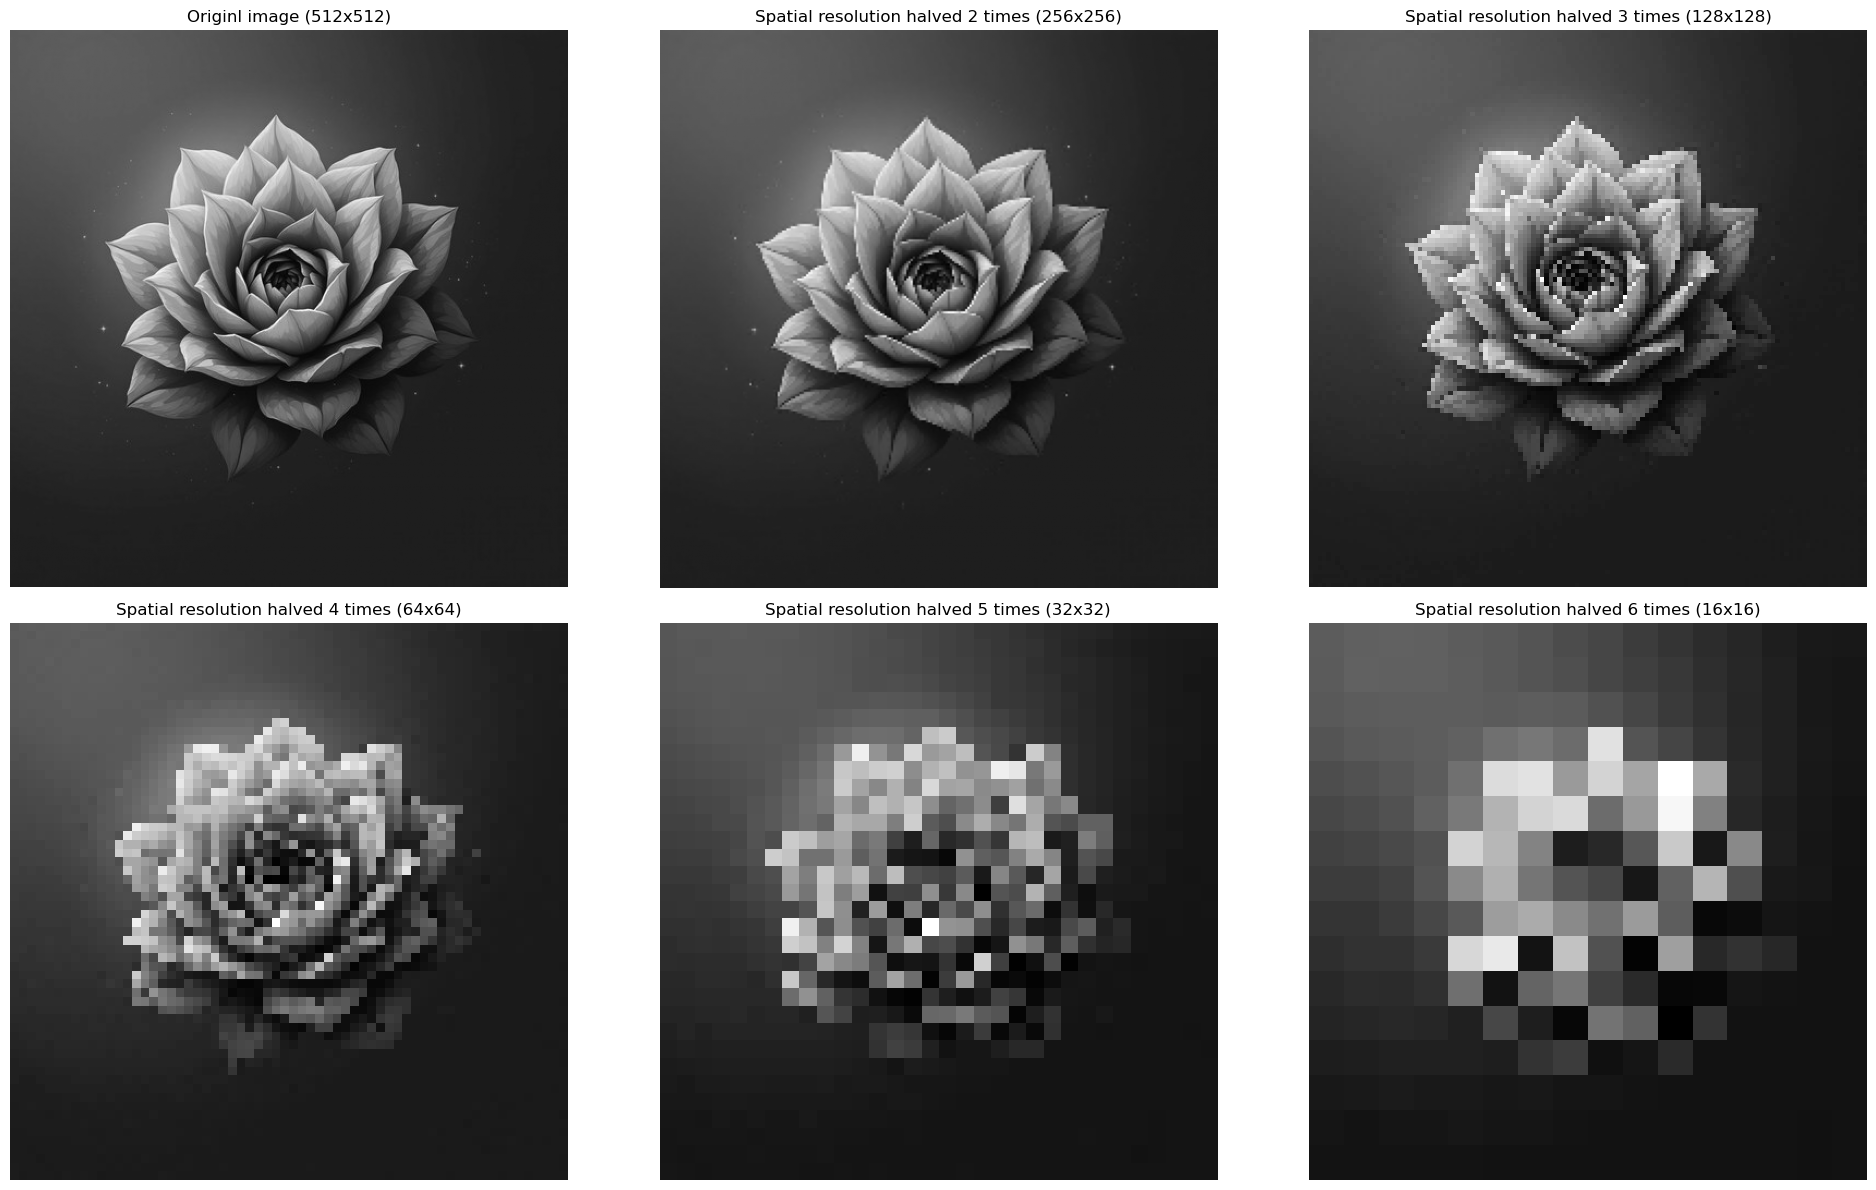

In [16]:
sizes = [(img.shape[1]//(2**i), img.shape[0]//(2**i)) for i in range(6)]
fig, axes = plt.subplots(2,3, figsize=(20,12))

for i, size in enumerate(sizes):
    resize_img = resize(img, size)
    row, col = divmod(i,3)
    axes[row,col].imshow(resize_img, cmap='gray')
    if i+1 == 1:
        axes[row, col].set_title(f"Originl image ({size[0]}x{size[1]})")
    else:
        axes[row, col].set_title(f"Spatial resolution halved {i+1} times ({size[0]}x{size[1]})")
    axes[row, col].axis('off')
plt.tight_layout()
plt.show()



(c) Decrease it intensity level resolution by one bit up to reach its binary format observe its change when displaying in the same window size

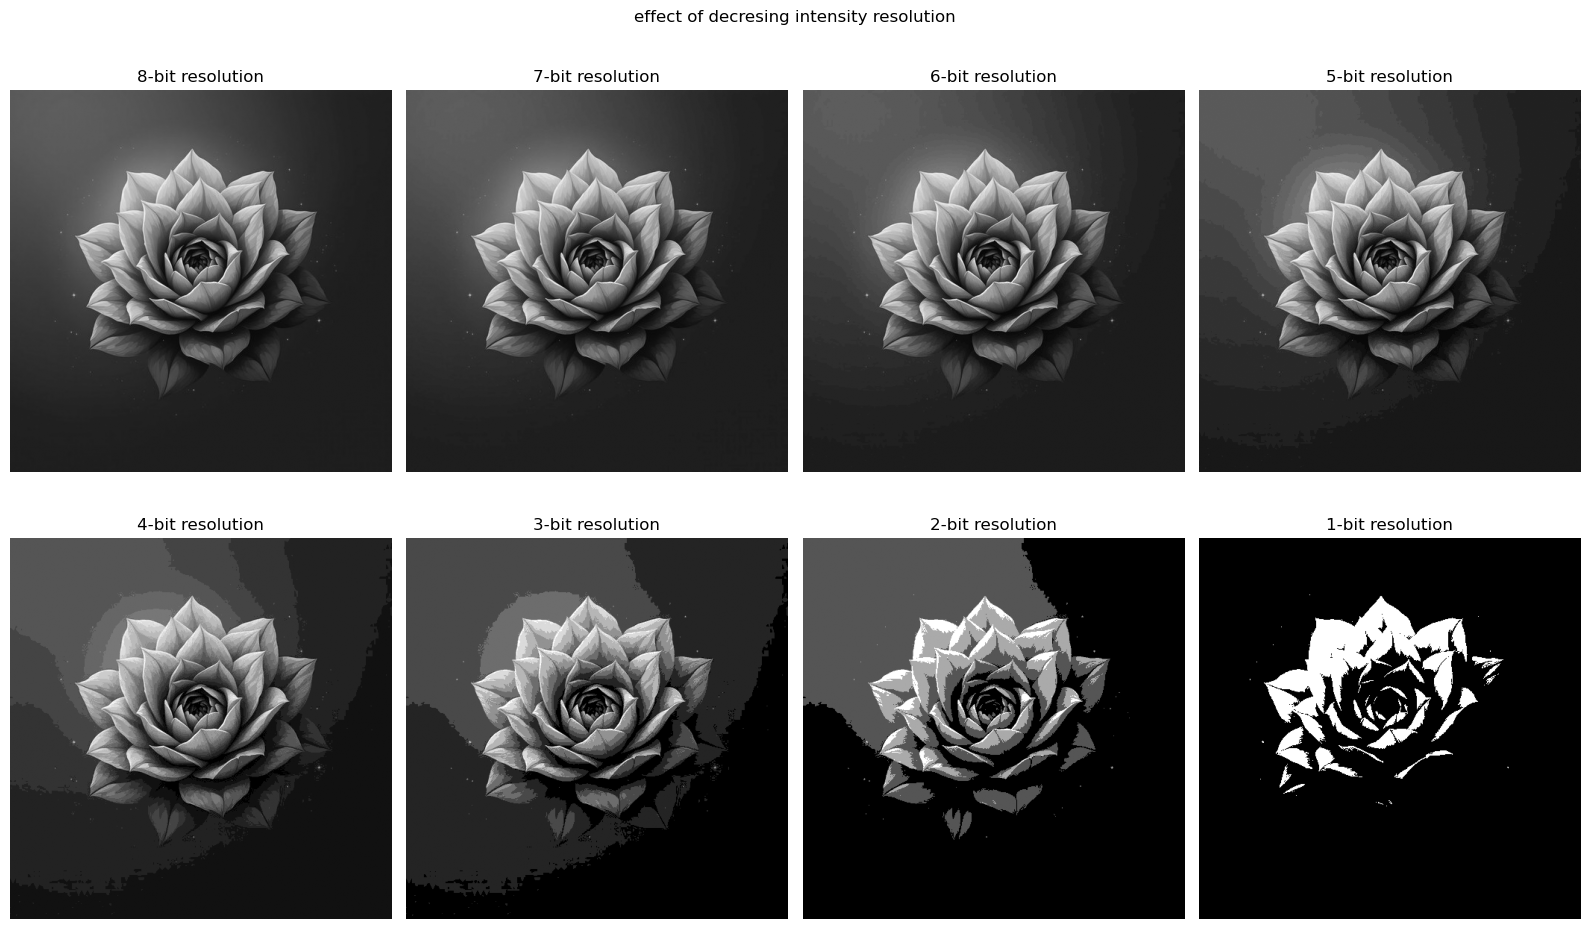

In [17]:
plt.figure(figsize=(16,10))

for i in range(8,0,-1):
    reduced_img = (img>>(8-i))<<(8-i)

    plt.subplot(2,4,9-i)
    plt.imshow(reduced_img, cmap='gray')
    plt.title(f'{i}-bit resolution')
    plt.axis('off')

plt.suptitle("effect of decresing intensity resolution")
plt.tight_layout()
plt.show()